# Lab 7: Explore Artificial Neural Network (ANN)

### Problem Overview

Design a nural network to predict student performance probability based on:
- Study Hours
- Sleep Hours

Network Architecture:
- Input Layer: 2 neurons
- Hidden Layer: 2 neurons
- Output Layer: 1 neuron
- Activation Function: Sigmoid
- Loss Function: Mean Squared Error (MSE)

#### Step 1: Data Preparation

In [1]:
import numpy as np

# dataset
X = np.array([
    [2,5],
    [4,6],
    [6,6],
    [8,7]
], dtype=float)

y = np.array([[0.2],[0.4],[0.7],[0.9]])

#### Step 2: Define helper functions

In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

# global variables
# hidden layer
w1,w2,w3,w4 = 0.2,-0.3,0.4,0.1
bias_h1,bias_h2 = 0.2,-0.1

# output layer
w5,w6,bias_o = -0.3,0.2,0.1
learning_rate = 0.1

#### Step 3: Analysis with single sample

In [10]:
def analyze_sample(x1, x2, target):
    
    global w1, w2, w3, w4, w5, w6, bias_h1, bias_h2, bias_o
        
    # (a) Hidden neuron input values
    h1_in = x1*w1 + x2*w3 + bias_h1
    h2_in = x1*w2 + x2*w4 + bias_h2
    
    print("\n(a) Hidden Neuron Input Values")
    print("h1_input =", h1_in)
    print("h2_input =", h2_in)
    
    # (b) Sigmoid activation
    h1 = sigmoid(h1_in)
    h2 = sigmoid(h2_in)
    
    print("\n(b) After Sigmoid Activation")
    print("h1 =", h1)
    print("h2 =", h2)
    
    # (c) Final output
    o_in = h1*w5 + h2*w6 + bias_o
    pred = sigmoid(o_in)
    
    print("\n(c) Final Output Value")
    print("Predicted =", pred)
    
    # (d) MSE Error
    mse = (target - pred)**2
    
    print("\n(d) Mean Squared Error =", mse)
    
    # # Observation
    # print("\nObservation")
    
    # if pred > target:
    #     print("Prediction is HIGHER than target")
    #     print("To reduce error → decrease output weights (w5, w6)")
    # else:
    #     print("Prediction is LOWER than target")
    #     print("To reduce error → increase output weights (w5, w6)")

### Question 1:
1. Using only the first training sample:
    - a. Compute the input values for the hidden neurons.
    - b. Apply the sigmoid activation function.
    - c. Compute the final output value.
    - d. Calculate the prediction error using Mean Squared Error.


In [5]:
print(X[0][0], X[0][1], y[0])
analyze_sample(X[0][0], X[0][1], y[0])

2.0 5.0 [0.2]

========== Using Training Sample ==========

(a) Hidden Neuron Input Values
h1_input = 2.6
h2_input = -0.19999999999999998

(b) After Sigmoid Activation
h1 = 0.9308615796566533
h2 = 0.45016600268752216

(c) Final Output Value
Predicted = 0.4777084685492589

(d) Mean Squared Error = [0.07712199]


Hidden Layer Weights: 
w1 = 0.2 
w2 = -0.3 
w3 = 0.4 
w4 = 0.1 
bias_h1 = 0.2 
bias_h2 = -0.1 
Output Layer Weights: 
w5 = -0.3 
w6 = 0.2 
bias_o = 0.1

Study Hours
Sleep Hours
Target Output
2 5 0.2
4 6 0.4
6 6 0.7
8 7 0.9

#### Answer to Question 1:
The input values for the hidden neurons:
- h1_input = 2*0.2 + 5*0.4 + 0.2 = 2.6
- h2_input = 2*(-0.3) + 5*0.1 - 0.1 = - 0.2

The activated outputs of the hidden neurons:
- h1 = sigmoid(2.6) ≈ 0.93
- h2 = sigmoid(-0.2) ≈ 0.45

The final output value:
- o_input = 0.93*(-0.3) + 0.45*0.2 + 0.1 ≈ 0.01
- predicted_output = sigmoid(0.01) ≈ 0.4777

The Mean Squared Error:
- MSE = (0.4777 - 0.2)^2 ≈ 0.077


#### Question 2:
2. Observe whether the predicted output is higher or lower than the target value. Identify which weights should increase or decrease in order to reduce the error.

#### Answer to Question 2:

The predicted output (0.4777) is higher than the target value (0.2). To reduce the error, we need to decrease the output weights (w5 and w6) to lower the final output value.

In [11]:
for i in range(len(X)):
    print(f"\n========== Using Training Sample {i} ==========")
    analyze_sample(X[i][0], X[i][1], y[i])
    


========== Using Training Sample 0 ==========

(a) Hidden Neuron Input Values
h1_input = 2.6
h2_input = -0.19999999999999998

(b) After Sigmoid Activation
h1 = 0.9308615796566533
h2 = 0.45016600268752216

(c) Final Output Value
Predicted = 0.4777084685492589

(d) Mean Squared Error = [0.07712199]

========== Using Training Sample 1 ==========

(a) Hidden Neuron Input Values
h1_input = 3.4000000000000004
h2_input = -0.6999999999999998

(b) After Sigmoid Activation
h1 = 0.9677045353015495
h2 = 0.33181222783183395

(c) Final Output Value
Predicted = 0.46905238264965826

(d) Mean Squared Error = [0.00476823]

========== Using Training Sample 2 ==========

(a) Hidden Neuron Input Values
h1_input = 3.8000000000000007
h2_input = -1.2999999999999998

(b) After Sigmoid Activation
h1 = 0.9781187290638694
h2 = 0.21416501695744142

(c) Final Output Value
Predicted = 0.46242034846791397

(d) Mean Squared Error = [0.05644409]

========== Using Training Sample 3 ==========

(a) Hidden Neuron Input V

### Additional:


Visualization of the neural Network structure and data points.

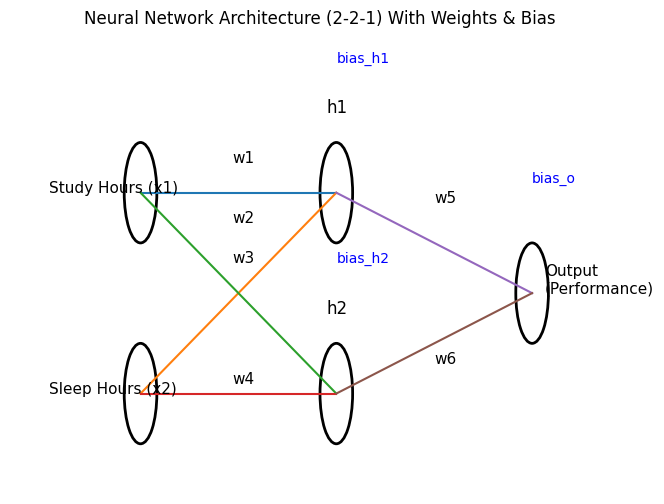

In [8]:
import matplotlib.pyplot as plt

def draw_nn_detailed():
    
    fig, ax = plt.subplots(figsize=(8,6))
    
    # neuron positions
    I1 = (0,2)
    I2 = (0,1)
    
    H1 = (3,2)
    H2 = (3,1)
    
    O1 = (6,1.5)
    
    # draw neurons
    for pos in [I1, I2, H1, H2, O1]:
        circle = plt.Circle(pos, 0.25, fill=False, linewidth=2)
        ax.add_patch(circle)
    
    # input labels
    ax.text(-1.4,2,"Study Hours (x1)", fontsize=11)
    ax.text(-1.4,1,"Sleep Hours (x2)", fontsize=11)
    
    # hidden labels
    ax.text(2.85,2.4,"h1", fontsize=12)
    ax.text(2.85,1.4,"h2", fontsize=12)
    
    # output label
    ax.text(6.2,1.5,"Output\n(Performance)", fontsize=11)
    
    # draw connections + weight labels
    
    # x1 → h1
    ax.plot([I1[0],H1[0]],[I1[1],H1[1]])
    ax.text(1.4,2.15,"w1", fontsize=11)
    
    # x2 → h1
    ax.plot([I2[0],H1[0]],[I2[1],H1[1]])
    ax.text(1.4,1.65,"w3", fontsize=11)
    
    # x1 → h2
    ax.plot([I1[0],H2[0]],[I1[1],H2[1]])
    ax.text(1.4,1.85,"w2", fontsize=11)
    
    # x2 → h2
    ax.plot([I2[0],H2[0]],[I2[1],H2[1]])
    ax.text(1.4,1.05,"w4", fontsize=11)
    
    # hidden → output
    
    ax.plot([H1[0],O1[0]],[H1[1],O1[1]])
    ax.text(4.5,1.95,"w5", fontsize=11)
    
    ax.plot([H2[0],O1[0]],[H2[1],O1[1]])
    ax.text(4.5,1.15,"w6", fontsize=11)
    
    # bias labels
    
    ax.text(3,2.65,"bias_h1", fontsize=10, color="blue")
    ax.text(3,1.65,"bias_h2", fontsize=10, color="blue")
    ax.text(6,2.05,"bias_o", fontsize=10, color="blue")
    
    ax.set_xlim(-2,7.5)
    ax.set_ylim(0.5,2.8)
    ax.axis("off")
    
    plt.title("Neural Network Architecture (2-2-1) With Weights & Bias")
    plt.show()

draw_nn_detailed()